## در این مثال دیتاست وقایع نامطلوب در چاه های نفت و گاز مورد استفاده قرار گرفته است. به منظور دسترسی به دیتاست، فایل های زیر را دانلود و در پوشه کاری از حالت فشرده خارج کنید.
https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-7/data.7z.001

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-7/data.7z.002

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-7/data.7z.003

https://github.com/hojatollahgholami/AI-in-Oil-and-gas-industry/blob/main/ex3-7/data.7z.004

ستون های دیتاست شامل موارد زیر است:

'P-PDG':Permanent Downhole Gauge (PDG)

'P-TPT': Pressure Transducer (TPT)

'T-TPT': Temperature Transducer (TPT)

'P-MON-CKP': Upstream pressure at the production line's choke point (Pa)

'T-JUS-CKP': Downstream temperature at the production line's choke point (°C).

'P-JUS-CKGL': Gas-lift injection pressure

'T-JUS-CKGL': Gas-lift injection temperature

'QGL': Gas-lift flow rate

'class':events_names کلاس خرابی که شامل
{0: 'Normal', 1: 'Abrupt Increase of BSW', 2: 'Spurious Closure of DHSV', 3: 'Severe Slugging', 4: 'Flow Instability', 5: 'Rapid Productivity Loss', 6: 'Quick Restriction in PCK', 7: 'Scaling in PCK', 8: 'Hydrate in Production Line' }}

### نصب کتابخانه ها در صورت نیاز

In [1]:
!pip install glob2 torch

### فراخوانی کتابخانه های مورد نیاز

In [2]:
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*weights_only=False.*")

from arabic_reshaper import reshape
from bidi.algorithm import get_display

### تعریف پارامترها و توابع کمکی

In [3]:
base_dir = "data"  # پوشه اصلی دیتاست
output_file = "3w_merged.parquet" # فایل تجمیع دیتاست

# تابع تبدیل متن فارسی برای نمایش در نمودارها
def fa(text):
    reshaped_text = reshape(text)
    return get_display(reshaped_text)

# تنظیمات فارسی نویسی
plt.rcParams["font.family"] = 'Adobe Arabic' 
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['font.size'] = 16

### بارگزاری تمامی فایل ها و سپس تجمیع در یک فایل

In [4]:
# بررسی وجود فایل نهایی برای جلوگیری از تکرار
if not os.path.exists(output_file):
    all_files = glob.glob(os.path.join(base_dir, "**/*.csv"), recursive=True)

    # پردازش فایل ها یکی یکی
    for i, file in enumerate(all_files, 1):
        print(f"Processing {i}/{len(all_files)}: {file}")
        chunk = pd.read_csv(file)

        # ذخیره تدریجی در فایل parquet
        chunk.to_parquet(output_file, engine="pyarrow", index=False)
else:
    print("فایل تجمیع شده موجود است:", output_file)

# بارگذاری برای استفاده بعدی
df = pd.read_parquet(output_file)
print("Final shape:", df.shape)
df.head(10)

فایل تجمیع شده موجود است: 3w_merged.parquet
Final shape: (24204, 10)


,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class
0,2017-05-09 01:35:17.000000,3.077460e+09,853155400.0,17.88542,1339768.0,NaN,1.401380e+09,NaN,0.059446,0.0
1,2017-05-09 01:35:18.000000,3.077460e+09,853175000.0,17.88626,1339595.0,NaN,1.401362e+09,NaN,0.059486,0.0
2,2017-05-09 01:35:19.000000,3.077460e+09,853194600.0,17.88710,1339422.0,NaN,1.401344e+09,NaN,0.059526,0.0
3,2017-05-09 01:35:20.000000,3.077460e+09,853189900.0,17.89255,1339250.0,NaN,1.401326e+09,NaN,0.059566,0.0
4,2017-05-09 01:35:21.000000,3.077459e+09,853185400.0,17.89799,1339077.0,NaN,1.401308e+09,NaN,0.059605,0.0
5,2017-05-09 01:35:22.000000,3.077458e+09,853180700.0,17.90343,1338904.0,NaN,1.401290e+09,NaN,0.059645,0.0
6,2017-05-09 01:35:23.000000,3.077457e+09,853176100.0,17.90887,1338731.0,NaN,1.401272e+09,NaN,0.059685,0.0
7,2017-05-09 01:35:24.000000,3.077457e+09,853171400.0,17.91432,1338558.0,NaN,1.401254e+09,NaN,0.059725,0.0
8,2017-05-09 01:35:25.000000,3.077456e+09,853176500.0,17.91556,1338385.0,NaN,1.401236e+09,NaN,0.059765,0.0
9,2017-05-09 01:35:26.000000,3.077456e+09,853181600.0,17.91679,1338212.0,NaN,1.401218e+09,NaN,0.059805,0.0


### پیش پردازش داده ها

In [5]:
print(df["class"].unique())
print(df.shape)

df = df[~((df["class"] == 108) | (df["class"].isna()))] # حذف کلاس 108 و گمشده ها
print(df.shape)

# تبدیل زمان
df["timestamp"] = pd.to_datetime(df["timestamp"])

# جدا کردن X و y
X = df.drop(columns=["timestamp", "class","T-JUS-CKP","T-JUS-CKGL"]).values 

y = df["class"].values
print('Unique classes after fix',np.unique(y))

print(X.shape,y.shape)
print(X)
print(y)
y = np.where(y == 8, 1, 0) #مدل CNN+LSTM برای آموزش نیاز دارد که مقادیر 0و1 باشد و 0و8 خطا خواهد داد. لذا مقدار 8 به 1 تبدیل می شود

[  0.  nan 108.   8.]
(24204, 10)
(3981, 10)
Unique classes after fix [0. 8.]
(3981, 6) (3981,)
[[3.077460e+09 8.531554e+08 1.788542e+01 1.339768e+06 1.401380e+09
  5.944592e-02]
 [3.077460e+09 8.531750e+08 1.788626e+01 1.339595e+06 1.401362e+09
  5.948579e-02]
 [3.077460e+09 8.531946e+08 1.788710e+01 1.339422e+06 1.401344e+09
  5.952566e-02]
 ...
 [3.096632e+09 1.910090e+09 4.311943e+00 3.150685e+06 1.578817e+09
  1.157273e-09]
 [3.096630e+09 1.909468e+09 4.312023e+00 3.150687e+06 1.578760e+09
  1.157232e-09]
 [3.096630e+09 1.908559e+09 4.311911e+00 3.150688e+06 1.578703e+09
  1.157190e-09]]
[0. 0. 0. ... 8. 8. 8.]


### آماده سازی دیتاست برای مدل سازی

In [6]:
# تابع آماده سازی دیتاست برای مدل سازی
# -----------------------
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len=50):
        self.X = X
        self.y = y
        self.seq_len = seq_len


    def __len__(self):
        return len(self.X) - self.seq_len


    def __getitem__(self, idx):
        X_seq = self.X[idx:idx+self.seq_len]
        y_label = self.y[idx+self.seq_len]
        return torch.tensor(X_seq, dtype=torch.float32), torch.tensor(y_label, dtype=torch.long)


SEQ_LEN = 50
batch_size = 64
dataset = TimeSeriesDataset(X, y, seq_len=SEQ_LEN)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


n_features = X.shape[1] # تعداد ویژگی ها
n_classes = len(np.unique(y))
print('n_classes:', np.unique(y))
print('0: normal, 1: anomaly')
print("n_features:", n_features, type(n_features))
print("n_classes:", n_classes, type(n_classes))

n_classes: [0 1]
0: normal, 1: anomaly
n_features: 6 <class 'int'>
n_classes: 2 <class 'int'>


In [7]:
# مدل CNN+LSTM
# -----------------------
class CNN_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, n_classes=2):
        super().__init__()
        # کانولوشن برای استخراج الگوهای محلی
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        # LSTM برای وابستگی های بلندمدت
        self.lstm = nn.LSTM(32, hidden_dim, num_layers=num_layers, batch_first=True)
        # لایه خروجی
        self.fc = nn.Linear(hidden_dim, n_classes)


    def forward(self, x):
        # x: [batch, seq_len, features]
        x = x.permute(0,2,1)          # [batch, features, seq_len]
        x = self.relu(self.conv1(x))  # [batch, 32, seq_len]
        x = x.permute(0,2,1)          # [batch, seq_len, 32]
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])


model = CNN_LSTM(input_dim=n_features, n_classes=n_classes)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### آموزش مدل کانولشنی و LSTM

Epoch 1/50, Loss: 0.4360
Epoch 2/50, Loss: 0.2368
Epoch 3/50, Loss: 0.1771
Epoch 4/50, Loss: 0.1373
Epoch 5/50, Loss: 0.1091
Epoch 6/50, Loss: 0.0885
Epoch 7/50, Loss: 0.0739
Epoch 8/50, Loss: 0.0629
Epoch 9/50, Loss: 0.0543
Epoch 10/50, Loss: 0.0482
Epoch 11/50, Loss: 0.0424
Epoch 12/50, Loss: 0.0380
Epoch 13/50, Loss: 0.0344
Epoch 14/50, Loss: 0.0314
Epoch 15/50, Loss: 0.0289
Epoch 16/50, Loss: 0.0266
Epoch 17/50, Loss: 0.0251
Epoch 18/50, Loss: 0.0230
Epoch 19/50, Loss: 0.0218
Epoch 20/50, Loss: 0.0201
Epoch 21/50, Loss: 0.0189
Epoch 22/50, Loss: 0.0178
Epoch 23/50, Loss: 0.0168
Epoch 24/50, Loss: 0.0159
Epoch 25/50, Loss: 0.0151
Epoch 26/50, Loss: 0.0142
Epoch 27/50, Loss: 0.0135
Epoch 28/50, Loss: 0.0129
Epoch 29/50, Loss: 0.0122
Epoch 30/50, Loss: 0.0122
Epoch 31/50, Loss: 0.0112
Epoch 32/50, Loss: 0.0107
Epoch 33/50, Loss: 0.0102
Epoch 34/50, Loss: 0.0098
Epoch 35/50, Loss: 0.0094
Epoch 36/50, Loss: 0.0090
Epoch 37/50, Loss: 0.0088
Epoch 38/50, Loss: 0.0083
Epoch 39/50, Loss: 0.

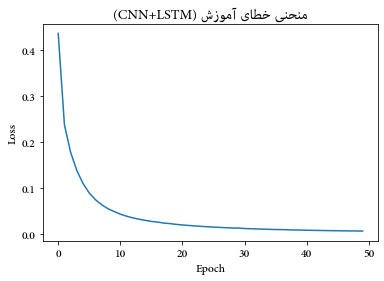

In [8]:
EPOCHS = 50
losses = []

for epoch in range(EPOCHS):
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)


        if torch.isnan(loss):
            print("داده NaN در خطا پیدا شد.")
            continue


        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # جلوگیری از انفجار گرادیان
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")
    
# 4) نمودار منحنی خطای آموزش
# -----------------------
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(fa("منحنی خطای آموزش (CNN+LSTM)"))
plt.show()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3467
           1       1.00      1.00      1.00       464

    accuracy                           1.00      3931
   macro avg       1.00      1.00      1.00      3931
weighted avg       1.00      1.00      1.00      3931



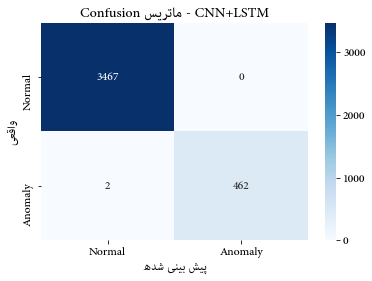

In [9]:
# ارزیابی
# -----------------------
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in loader:
        preds = model(X_batch)
        all_preds.extend(torch.argmax(preds, dim=1).cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())



print(classification_report(all_labels, all_preds))


cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
plt.xlabel(fa("پیش بینی شده"))
plt.ylabel(fa("واقعی"))
plt.title(fa("Confusion ماتریس - CNN+LSTM"))
plt.show()